# When the Heuristic Points Backwards

Predicting content decline across 37 client portfolios — and finding three reasons the
result could not be trusted as stated.

**Noah Chapman · FlyRank ML Internship, Lane 2 · September 2026**

Deployed paper: https://chapcoda.github.io/flyrank-ML-starter/

## 0. Set Up

In [ ]:
# ============ SETUP (self-contained — safe to re-run any time) ============
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb", "huggingface_hub"], check=True)

from huggingface_hub import login
from google.colab import userdata
HF_TOKEN = userdata.get("HF_TOKEN")
login(token=HF_TOKEN)

import duckdb
import pandas as pd
import numpy as np
import sklearn
print("sklearn:", sklearn.__version__)

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
);
""")

DATASET = "hf://datasets/FlyRank/internship-warehouse"
DIM_CONTENT = f"{DATASET}/dim_content.parquet"

FEAT_MONTHS = ["2026-02", "2026-03", "2026-04"]
FEAT_PATHS = [f"{DATASET}/fact_content_daily_performance/month={m}/data_0.parquet" for m in FEAT_MONTHS]
FEAT_UNION_SQL = " UNION ALL ".join([f"SELECT * FROM read_parquet('{p}')" for p in FEAT_PATHS])

print("Setup complete. Working dir:", os.getcwd())

# ============ FEATURE TABLE — Feb 1 - Apr 30 2026, per Week 3 data contract ============
q_features = f"""
WITH feature_window AS (
    {FEAT_UNION_SQL}
),
perf AS (
    SELECT
        content_hash_id,
        client_hash_id,
        SUM(CASE WHEN gsc_data_available = TRUE THEN gsc_impressions ELSE 0 END) AS impressions_90d,
        SUM(CASE WHEN gsc_data_available = TRUE THEN gsc_clicks ELSE 0 END) AS clicks_90d,
        SUM(CASE WHEN gsc_data_available = TRUE THEN gsc_avg_position * gsc_impressions ELSE 0 END)
            / NULLIF(SUM(CASE WHEN gsc_data_available = TRUE THEN gsc_impressions ELSE 0 END), 0)
            AS avg_position_weighted,
        SUM(CASE WHEN ga4_data_available = TRUE THEN ga4_sessions ELSE 0 END) AS sessions_90d,
        SUM(CASE WHEN ga4_data_available = TRUE THEN ga4_engaged_sessions ELSE 0 END) AS engaged_sessions_90d,
        SUM(CASE WHEN ga4_data_available = TRUE THEN ga4_total_engagement_sec ELSE 0 END) AS engagement_sec_90d,
        SUM(CASE WHEN ga4_data_available = TRUE THEN sessions_organic ELSE 0 END) AS sessions_organic_90d,
        BOOL_OR(gsc_data_available) AS any_gsc_available,
        BOOL_OR(ga4_data_available) AS any_ga4_available
    FROM feature_window
    GROUP BY content_hash_id, client_hash_id
),
dims AS (
    SELECT
        content_hash_id,
        client_hash_id,
        content_type,
        main_intent,
        backlinks,
        char_count,
        word_count,
        search_volume,
        competition,
        competition_level,
        cpc,
        DATE_DIFF('day', content_created_date, DATE '2026-04-30') AS content_age_days,
        DATE_DIFF('day', content_updated_date, DATE '2026-04-30') AS days_since_last_update,
        DATE_DIFF('day', last_optimized_date, DATE '2026-04-30') AS days_since_last_optimized
    FROM read_parquet('{DIM_CONTENT}')
    WHERE is_published = TRUE
      AND is_deleted = FALSE
)
SELECT
    d.content_hash_id,
    d.client_hash_id,
    d.content_type,
    d.main_intent,
    d.backlinks,
    d.char_count,
    d.word_count,
    d.search_volume,
    d.competition,
    d.competition_level,
    d.cpc,
    d.content_age_days,
    d.days_since_last_update,
    d.days_since_last_optimized,
    COALESCE(p.impressions_90d, 0) AS impressions_90d,
    COALESCE(p.clicks_90d, 0) AS clicks_90d,
    p.avg_position_weighted,
    COALESCE(p.sessions_90d, 0) AS sessions_90d,
    COALESCE(p.engaged_sessions_90d, 0) AS engaged_sessions_90d,
    COALESCE(p.engagement_sec_90d, 0) AS engagement_sec_90d,
    COALESCE(p.sessions_organic_90d, 0) AS sessions_organic_90d,
    COALESCE(p.any_gsc_available, FALSE) AS any_gsc_available,
    COALESCE(p.any_ga4_available, FALSE) AS any_ga4_available
FROM dims d
LEFT JOIN perf p ON d.content_hash_id = p.content_hash_id
WHERE d.days_since_last_update >= 0
"""

features = con.execute(q_features).fetchdf()

features["ctr"] = np.where(
    features["impressions_90d"] > 0,
    features["clicks_90d"] / features["impressions_90d"],
    0.0,
)
features["engagement_rate"] = np.where(
    features["sessions_90d"] > 0,
    features["engaged_sessions_90d"] / features["sessions_90d"],
    0.0,
)

print(f"Feature table: {len(features):,} rows, {features['client_hash_id'].nunique()} clients")

sklearn: 1.6.1
Setup complete. Working dir: /content/flyrank-ml-internship-starter


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature table: 50,840 rows, 37 clients


In [ ]:
# ============ LABEL — is_declining_label, per Week 3 data contract ============
TRAILING_PATH = f"{DATASET}/fact_content_daily_performance/month=2026-04/data_0.parquet"
TARGET_PATH   = f"{DATASET}/fact_content_daily_performance/month=2026-05/data_0.parquet"

q_label = f"""
WITH trailing_30d AS (
    SELECT content_hash_id,
           SUM(CASE WHEN gsc_data_available = TRUE THEN gsc_impressions ELSE 0 END) AS trailing_impressions
    FROM read_parquet('{TRAILING_PATH}')
    GROUP BY content_hash_id
),
target_window AS (
    SELECT content_hash_id,
           SUM(CASE WHEN gsc_data_available = TRUE THEN gsc_impressions ELSE 0 END) AS target_impressions,
           BOOL_OR(gsc_data_available) AS any_may_gsc
    FROM read_parquet('{TARGET_PATH}')
    GROUP BY content_hash_id
)
SELECT
    t.content_hash_id,
    t.trailing_impressions,
    COALESCE(g.target_impressions, 0) AS target_impressions,
    COALESCE(g.any_may_gsc, FALSE) AS any_may_gsc,
    CASE
        WHEN t.trailing_impressions > 0
            THEN CASE WHEN COALESCE(g.target_impressions, 0) <= t.trailing_impressions * 0.75
                      THEN 1 ELSE 0 END
        ELSE NULL
    END AS is_declining_label
FROM trailing_30d t
LEFT JOIN target_window g ON t.content_hash_id = g.content_hash_id
"""

labels = con.execute(q_label).fetchdf()

model_df = features.merge(
    labels[["content_hash_id", "is_declining_label", "any_may_gsc"]],
    on="content_hash_id", how="inner")
model_df = model_df.dropna(subset=["is_declining_label"]).copy()
model_df["is_declining_label"] = model_df["is_declining_label"].astype(int)

print(f"Final modeling table: {len(model_df):,} rows, {model_df['client_hash_id'].nunique()} clients")
print(f"Declining rate: {model_df['is_declining_label'].mean():.1%}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Final modeling table: 33,296 rows, 29 clients
Declining rate: 50.2%


In [ ]:
# ============ MODEL, BASELINE, SPLIT, QUEUE ============
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score

# days_since_last_optimized excluded — 100% null, verified inert (w06)
numeric_features = [
    "char_count", "word_count", "search_volume", "competition", "cpc",
    "content_age_days", "days_since_last_update",
    "impressions_90d", "clicks_90d", "avg_position_weighted",
    "sessions_90d", "engaged_sessions_90d", "engagement_sec_90d",
    "sessions_organic_90d", "ctr", "engagement_rate",
]
categorical_features = ["content_type", "main_intent", "competition_level"]
ALL_FEATURES = numeric_features + categorical_features

pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])
model = Pipeline([("preprocess", pre), ("clf", RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5, class_weight="balanced",
    random_state=42, n_jobs=1))])

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(splitter.split(model_df, groups=model_df["client_hash_id"]))
train_df = model_df.iloc[tr_idx].reset_index(drop=True)
queue_df = model_df.iloc[te_idx].reset_index(drop=True)

model.fit(train_df[ALL_FEATURES], train_df["is_declining_label"])
queue_df["risk_score"] = model.predict_proba(queue_df[ALL_FEATURES])[:, 1]

def precision_at_k(df, col, k=50):
    return df.nlargest(k, col)["is_declining_label"].mean()

print(f"Train: {len(train_df):,} rows, {train_df['client_hash_id'].nunique()} clients")
print(f"Test:  {len(queue_df):,} rows, {queue_df['client_hash_id'].nunique()} clients")
print(f"Test base rate: {queue_df['is_declining_label'].mean():.3f}\n")

# Per-client queue (w07 design)
client_stats = queue_df.groupby("client_hash_id").agg(
    pos_p75=("avg_position_weighted", lambda s: s.quantile(0.75)),
    ctr_p25=("ctr", lambda s: s.quantile(0.25)),
    imp_median=("impressions_90d", "median"),
    update_p75=("days_since_last_update", lambda s: s.quantile(0.75)),
).to_dict("index")

def reason_category(row):
    c = client_stats[row["client_hash_id"]]
    cats = []
    if pd.notna(row["avg_position_weighted"]) and row["avg_position_weighted"] > c["pos_p75"]:
        cats.append("ranks_deep")
    if row["impressions_90d"] > c["imp_median"] and row["ctr"] <= c["ctr_p25"]:
        cats.append("visible_low_ctr")
    elif row["ctr"] <= c["ctr_p25"] and row["impressions_90d"] > 0:
        cats.append("low_ctr")
    if row["days_since_last_update"] > c["update_p75"]:
        cats.append("stale_for_client")
    if row["impressions_90d"] == 0:
        cats.append("no_impressions")
    return "+".join(cats) if cats else "no_dominant_driver"

queue_df["reason_category"] = queue_df.apply(reason_category, axis=1)

queue = (queue_df.sort_values(["client_hash_id", "risk_score"], ascending=[True, False])
         .groupby("client_hash_id").head(10).copy())
queue["rank_in_client"] = queue.groupby("client_hash_id")["risk_score"].rank(
    ascending=False, method="first").astype(int)

print(f"\nQueue: {len(queue)} pages across {queue['client_hash_id'].nunique()} clients")
print(f"Queue hit rate: {queue['is_declining_label'].mean():.1%}")

Train: 30,819 rows, 23 clients
Test:  2,477 rows, 6 clients
Test base rate: 0.506


Queue: 52 pages across 6 clients
Queue hit rate: 59.6%


## 1. Question

### The research question

**Can a model predict which published pages are about to lose search visibility, in
time for a content team to act?**

Concretely: using only data available on 30 April 2026, can we rank a client's pages so
that the ones which go on to lose impressions in May appear near the top?

### The decision it supports

An SEO agency has more pages than review hours. A team managing tens of thousands of
pages across dozens of clients cannot inspect them all, so the practical question is
never "which pages are declining" — it is "which twenty should I look at this week."
That makes this a ranking problem rather than a classification problem, and it is why
the metric throughout is Precision@K rather than accuracy.

### Why this turned out to be a paper about measurement

The starting hypothesis came from industry convention and from FlyRank's own published
research: content decays as it goes stale, so pages that have not been updated recently
are the ones at risk. Week 4 built exactly that rule — rank by days since last update.

It did not merely perform poorly. It scored a ROC AUC of **0.298**, which is not a weak
result but an *inverted* one. A rule scoring 0.5 has no information; this rule scored
below chance, meaning it ranked pages consistently wrong. Inverting its output would
have produced roughly 0.70.

Explaining that inversion is what this paper is actually about. Pursuing it surfaced
three findings that bear on the result more than the model does:

1. **The label was contaminated in one direction.** Missing search-console coverage in
   the outcome month could only ever produce a "declining" label, never a "stable" one,
   affecting 17.7% of positive labels.
2. **The evaluation metric was unstable.** Precision@50 moved between 0.52 and 0.66
   across runs of an identical pipeline with a fixed seed, while ROC AUC stayed within
   0.002.
3. **The feature the original rule was built on had almost no variance.** Days since
   last update had a median of 64 and a 75th percentile of 64 across the training
   window — there was no staleness variation available to learn from, in either
   direction.

A machine-learning model was built, and it does rank better than the baseline. But the
honest contribution of this work is the account of why that improvement is harder to
measure than it looks, and what would have to be fixed before anyone acted on it.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [ ]:
# ============ SECTION 2 — DATA ============
import pandas as pd

print("SOURCE")
print("-" * 62)
print("Release:  FlyRank/internship-warehouse (Hugging Face, Parquet)")
print("Tables:   dim_content, fact_content_daily_performance")
print("Access:   DuckDB over hf:// — columns and partitions read on demand,")
print("          never the full ~79M-row table")

print("\nWINDOWS")
print("-" * 62)
print("Features: 2026-02-01 to 2026-04-30  (3 monthly partitions)")
print("Trailing: 2026-04-01 to 2026-04-30  (label denominator)")
print("Outcome:  2026-05-01 to 2026-05-31  (label numerator)")

print("\nFUNNEL — what survived each filter")
print("-" * 62)
rows = [
    ("dim_content, published and not deleted, joined to Feb-Apr performance",
     len(features), features["client_hash_id"].nunique()),
    ("...with a defined label (April trailing impressions > 0)",
     len(model_df), model_df["client_hash_id"].nunique()),
    ("...held out from training (client-grouped split)",
     len(queue_df), queue_df["client_hash_id"].nunique()),
]
for label, n, c in rows:
    print(f"{n:>8,} rows  {c:>3} clients   {label}")

print(f"\nExcluded for undefined label: {len(features) - len(model_df):,} rows "
      f"({(len(features)-len(model_df))/len(features):.1%})")

print("\nCOVERAGE — the trap this dataset sets")
print("-" * 62)
print(f"Feature-window GSC honest coverage: {model_df['any_gsc_available'].mean():.1%}")
print(f"Feature-window GA4 honest coverage: {model_df['any_ga4_available'].mean():.1%}")
print(f"Outcome-window GSC honest coverage: {model_df['any_may_gsc'].mean():.1%}")

print("\nCLASS BALANCE")
print("-" * 62)
print(f"Declining: {model_df['is_declining_label'].mean():.1%}")
print(f"Per-client range: "
      f"{model_df.groupby('client_hash_id')['is_declining_label'].mean().min():.0%} - "
      f"{model_df.groupby('client_hash_id')['is_declining_label'].mean().max():.0%}")

import numpy as np
by_client = model_df.groupby("client_hash_id").agg(
    pages=("is_declining_label", "size"),
    declining=("is_declining_label", "mean"),
    may_gsc=("any_may_gsc", "mean"))
sub = by_client[by_client["pages"] >= 30]
r = np.corrcoef(sub["may_gsc"], sub["declining"])[0, 1]
print(f"clients with >=30 pages: {len(sub)}")
print(f"corr(May GSC coverage, declining rate) = {r:+.3f}\n")
band = sub.assign(band=pd.cut(sub["may_gsc"], [0, .5, .8, .95, 1.0])).groupby(
    "band", observed=True).agg(clients=("declining", "size"),
                               mean_declining=("declining", "mean"))
print(band.round(3).to_string())

SOURCE
--------------------------------------------------------------
Release:  FlyRank/internship-warehouse (Hugging Face, Parquet)
Tables:   dim_content, fact_content_daily_performance
Access:   DuckDB over hf:// — columns and partitions read on demand,
          never the full ~79M-row table

WINDOWS
--------------------------------------------------------------
Features: 2026-02-01 to 2026-04-30  (3 monthly partitions)
Trailing: 2026-04-01 to 2026-04-30  (label denominator)
Outcome:  2026-05-01 to 2026-05-31  (label numerator)

FUNNEL — what survived each filter
--------------------------------------------------------------
  50,840 rows   37 clients   dim_content, published and not deleted, joined to Feb-Apr performance
  33,296 rows   29 clients   ...with a defined label (April trailing impressions > 0)
   2,477 rows    6 clients   ...held out from training (client-grouped split)

Excluded for undefined label: 17,544 rows (34.5%)

COVERAGE — the trap this dataset sets
-----------

### Source

The FlyRank ML Internship warehouse release (`FlyRank/internship-warehouse`), a
pseudonymised export of production search performance hosted as Parquet on Hugging
Face. Two tables are used: `dim_content` for page metadata, and
`fact_content_daily_performance` for daily per-page search and analytics metrics.

The daily fact table holds roughly 79 million rows. It is never downloaded. DuckDB
reads directly over `hf://`, touching only the columns and monthly partitions each query
needs, which keeps the whole analysis inside a free Colab session.

All identifiers in this paper are hashed. No client names, page URLs, or search queries
appear anywhere in the dataset or in this work.

### Windows

| window | dates | role |
|---|---|---|
| Feature | 2026-02-01 to 2026-04-30 | everything the model is allowed to see |
| Trailing | 2026-04-01 to 2026-04-30 | denominator of the outcome definition |
| Outcome | 2026-05-01 to 2026-05-31 | numerator of the outcome definition |

The separation is deliberate: a model that is supposed to give a content team lead time
must be restricted to what was knowable on 30 April. No May data enters any feature.

### What was excluded, and what that costs

| rows | clients | filter |
|---|---|---|
| 50,840 | 37 | published, not deleted, joined to Feb–Apr performance |
| 33,296 | 29 | with a defined outcome label |
| 2,477 | 6 | held out from training for evaluation |

**17,544 pages — 34.5% of the portfolio — were dropped for having an undefined label.**
These are pages with zero April impressions. A page that earned nothing in April cannot
meaningfully decline by 25% in May; the ratio is undefined. Excluding them is correct,
but it narrows the scope of every claim in this paper: this work is about pages that had
measurable search visibility going in. It says nothing about pages that never achieved
any, which is a third of the inventory and arguably a content team's larger problem.

Eight clients disappear between the first and second rows, having no pages with a
defined label at all.

### Coverage — the trap this dataset sets

The warehouse carries explicit `gsc_data_available` and `ga4_data_available` flags,
because a client's data connection can lapse. When it does, the underlying metrics
arrive as zeros that mean "not measured" rather than "measured as nothing."

| window | GSC | GA4 |
|---|---|---|
| Feature (Feb–Apr) | 100.0% | 55.5% |
| Outcome (May) | 91.1% | — |

Every feature aggregate in this work is guarded by a `CASE WHEN gsc_data_available =
TRUE` filter, so no dishonest zero enters the model's inputs. Feature-window coverage is
complete, which means the model reads observed data for every page it scores.

The outcome window is 91.1%, and that gap is where this paper's central methodological
finding lives. Section 3 sets it out.

GA4 coverage at 55.5% is a separate and quieter problem: nearly half the portfolio has
no honest engagement data, so every session, scroll, and engagement feature is imputed
for those pages. Anything this work appears to conclude about on-page behaviour rests on
a portfolio median for half its rows.

### Class balance

The outcome is close to balanced by construction — 50.2% of labelled pages are marked
declining, because a 25% month-over-month drop is roughly a coin flip in this portfolio.
No class weighting was needed on that account.

Per client, it is not balanced at all: **the declining rate ranges from 0% to 100%
across the 29 clients.** At least one client has every labelled page declining; at least
one has none. That range is the single most important fact in this section. It means a
portfolio-level accuracy figure describes no individual client, and it is the reason
every evaluation in this paper is reported per client as well as in aggregate.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [ ]:
# ============ SECTION 3 — METHODOLOGY ============
import numpy as np

print("FEATURE SET")
print("-" * 62)
print(f"{len(numeric_features)} numeric + {len(categorical_features)} categorical = {len(ALL_FEATURES)} features")
print("\nExcluded by the Week 3 data contract (label-derived):")
print("  trend_direction, trend_pct, is_declining_label")
print("Excluded as inert:")
print("  days_since_last_optimized (100% null — verified no effect on results)")

print("\nFEATURE VARIANCE — what the model could actually learn from")
print("-" * 62)
var_check = train_df[["avg_position_weighted", "ctr", "impressions_90d",
                      "days_since_last_update", "content_age_days"]].describe(
    ).loc[["mean", "std", "25%", "50%", "75%"]].round(2)
print(var_check.to_string())

print("\nNULL COVERAGE IN THE FEATURE SET")
print("-" * 62)
nulls = (model_df[ALL_FEATURES].isna().mean() * 100).round(1)
print(nulls[nulls > 0].sort_values(ascending=False).to_string())

print("\nLEAKAGE CHECK — label-derived columns in the feature set")
print("-" * 62)
banned = ["trend_direction", "trend_pct", "is_declining_label",
          "target_impressions", "trailing_impressions", "any_may_gsc"]
print(f"Present: {[c for c in ALL_FEATURES if c in banned] or 'none'}")

print("\nLEAKAGE CHECK — April is in both the feature window and the label denominator")
print("-" * 62)
for f in ["impressions_90d", "clicks_90d", "avg_position_weighted"]:
    s = model_df[[f, "is_declining_label"]].dropna()
    print(f"  corr({f:22s}, label) = {np.corrcoef(s[f], s['is_declining_label'])[0,1]:+.4f}")
print("\nMean by class:")
print(model_df.groupby("is_declining_label")[
    ["impressions_90d", "clicks_90d", "avg_position_weighted"]].mean().round(2).to_string())

print("\nSPLIT DESIGN — why client-grouped")
print("-" * 62)
print(f"Naive row-level split would put the same client on both sides.")
print(f"Client-grouped: {train_df['client_hash_id'].nunique()} train clients, "
      f"{queue_df['client_hash_id'].nunique()} test clients, zero overlap.")
print(f"Train {len(train_df):,} rows / Test {len(queue_df):,} rows")

FEATURE SET
--------------------------------------------------------------
16 numeric + 3 categorical = 19 features

Excluded by the Week 3 data contract (label-derived):
  trend_direction, trend_pct, is_declining_label
Excluded as inert:
  days_since_last_optimized (100% null — verified no effect on results)

FEATURE VARIANCE — what the model could actually learn from
--------------------------------------------------------------
      avg_position_weighted   ctr  impressions_90d  days_since_last_update  content_age_days
mean                  18.33  0.00          2893.71                   55.85            226.63
std                   17.62  0.01          9142.90                   34.94             77.19
25%                    5.94  0.00           131.00                   64.00            183.00
50%                   10.97  0.00           553.00                   64.00            224.00
75%                   25.72  0.00          2395.00                   64.00            289.00

NULL C

### Assumptions

Three, stated so a reader can reject them.

**A page's near-future search performance is partly predictable from its recent
performance and its static properties.** If decline were driven entirely by external
events — algorithm updates, competitor moves, seasonality — no feature available here
would help.

**A 25% month-over-month drop in impressions is a meaningful adverse outcome.** The
threshold is a convention, chosen because it produces a near-balanced class split in
this portfolio. A different threshold would define a different problem.

**Pages within a client are more alike than pages across clients.** This assumption
drives the validation design, and Section 4 shows it is correct by a wide margin.

### Features

Nineteen features — sixteen numeric, three categorical — drawn entirely from the
Feb–April window and from static page metadata.

Search performance: impressions, clicks, impression-weighted average position, CTR.
Analytics: sessions, engaged sessions, engagement seconds, organic sessions, engagement
rate. Content: character count, word count, content age, days since last update.
Market: search volume, competition score, CPC. Categorical: content type, main intent,
competition level.

**Excluded by the Week 3 data contract as label-derived:** `trend_direction`,
`trend_pct`, `is_declining_label`. These encode the outcome and would leak it directly.

**Excluded as inert:** `days_since_last_optimized`, which is 100% null. It was carried
in the first model version before being detected; removing it changed Precision@50 and
ROC AUC by nothing at all, because the imputer had been silently skipping the column
throughout.

### Two features are more than half missing

| feature | % null |
|---|---|
| char_count | 52.2 |
| word_count | 52.2 |
| competition_level / main_intent | 6.0 |
| search_volume / competition / cpc | 5.7 |

`char_count` and `word_count` are null for over half the modelling table and are
median-imputed. Any apparent conclusion about content depth in this work rests on a
fabricated value for the majority of rows, and no claim is made about depth anywhere in
this paper.

### The feature the baseline was built on is degenerate in the middle

`days_since_last_update` has a standard deviation of 34.94, so it varies overall. But
its 25th, 50th, and 75th percentiles are **all exactly 64** — half the portfolio sits on
a single value, with variation only in the tails.

That matters for interpreting the results. A tree-based model splits on thresholds; a
feature where the entire interquartile range collapses to one number offers almost no
threshold worth splitting on. When Section 4 reports that this feature contributed
nothing measurable, the honest reading is not "content freshness does not predict
decline." It is that **this window could not test the question**, because the pages in
it were nearly all updated at the same time.

### Label definition — and a contamination found in it

The outcome is binary. A page is labelled **declining** if its May impressions are at or
below 75% of its April impressions, **stable** otherwise, and **undefined** if it had
zero April impressions.

The implementation used `COALESCE(may_impressions, 0)`, so a page absent from the May
partition was treated as having earned zero impressions in May.

**Zero always clears the 0.75× threshold.** So missing outcome data can only ever
produce a "declining" label, and can never produce a "stable" one. The contamination is
one-directional by construction:

| label | pages | with no honest May GSC data |
|---|---|---|
| declining | 16,711 | 2,964 (17.7%) |
| stable | 16,585 | 0 (0.0%) |

This is not a rare edge case. Across the 22 clients with at least 30 labelled pages, the
correlation between a client's May GSC coverage and its apparent decline rate is
**−0.517**:

| May GSC coverage | clients | mean decline rate |
|---|---|---|
| 0–50% | 2 | 0.894 |
| 50–80% | 10 | 0.589 |
| 80–95% | 4 | 0.517 |
| 95–100% | 6 | 0.567 |

The two clients with broken coverage show an 89% apparent decline rate. Clients with
functioning coverage cluster between 52% and 59%. A substantial part of what this label
records is whether a client's analytics connection was working, not whether their
content lost visibility.

Two honest qualifications. The relationship is driven mainly by the two extreme
low-coverage clients — the upper three bands are nearly flat — and 22 clients is a small
sample for a correlation. This is suggestive evidence at portfolio level supporting a
mechanism that is certain at row level.

**The fix is known and scoped: restrict the label to pages with honest May coverage.**
It is not applied in this paper. Applying it would change every number reported here,
and this work's contribution is the identification and measurement of the problem rather
than a corrected model. Restricting to clean labels does narrow the per-client decline
range at the top (0.96 → 0.91) but widens it at the bottom (0.38 → 0.27), so real
between-client variation survives the correction — the contamination is not the whole
explanation for it.

Why this generalises: `COALESCE(x, 0)` is a routine SQL idiom and correct in most
contexts. Here it silently converts a data-availability event into an outcome, in one
direction, invisibly from any results table. Nothing about the model's output would
reveal it.

### Baseline

The Week 4 baseline ranks pages by a staleness weight multiplied by log-dampened
impressions — the industry heuristic that stale content decays, with visibility used to
break ties. It is evaluated on exactly the same split, the same rows, and the same
metric as the model.

### Validation design

**Client-grouped holdout.** Clients are split 80/20 by `GroupShuffleSplit`, so no client
appears in both training and test: 23 training clients (30,819 rows), 6 test clients
(2,477 rows), zero overlap.

This matters more than it might seem, and Section 4 quantifies it. A naive row-level
split lets the model recognise a client from pages it has already seen, which inflates
the result substantially and measures something that never occurs in deployment.

**Model:** `RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
class_weight='balanced', random_state=42, n_jobs=1)`, with median imputation for numeric
features and one-hot encoding for categoricals, inside a single pipeline fitted on
training data only.

`n_jobs=1` is deliberate. Section 4 explains why.

**Metric:** Precision@50 as the primary metric, because the decision this supports is
"which pages do I review this week." ROC AUC is reported alongside, and Section 4 shows
why it is the more trustworthy of the two here.

### Leakage checks

**Label-derived features:** none present. All 19 features checked against the banned
list plus the intermediate label columns.

**April in both windows.** April sits inside the feature window and is the label's
denominator, raising the possibility that the model learns mean reversion — pages with
high recent impressions have further to fall — rather than decline risk. Tested:

| feature | correlation with label |
|---|---|
| impressions_90d | −0.0129 |
| clicks_90d | −0.0703 |
| avg_position_weighted | −0.1313 |

All three are weak and negative. Declining pages have *fewer* impressions (2,633 vs
2,861) and fewer clicks (4.5 vs 9.2) than stable ones — the opposite of what mean
reversion predicts. The hypothesis is tested and rejected.

One result there is genuinely odd and is not explained away: declining pages have a
**better** average position (16.2 vs 20.8). Higher-ranking pages should not be more
likely to decline. The most plausible reading connects to the contamination above —
pages pulled into the declining class by missing May data carry whatever Feb–April
position they had, including good ones. Confirming that requires re-running under the
corrected label, which this paper does not do.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
# ============ SECTION 4 — RESULTS VS BASELINE ============
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.base import clone
import pandas as pd, numpy as np

def p_at_k(df, col, k=50):
    return df.nlargest(k, col)["is_declining_label"].mean()

# ---- Week 4 baseline, faithfully reproduced on the capstone's split ----
bucket_weights = {
    "1) 0-30d":    9.8 / 51.6,
    "2) 31-90d":  51.6 / 51.6,
    "3) 91-180d":  3.4 / 51.6,
    "4) 181-365d": 0.4 / 51.6,
    "5) 365+d":    0.1 / 51.6,
}

def age_bucket(d):
    if d <= 30:  return "1) 0-30d"
    if d <= 90:  return "2) 31-90d"
    if d <= 180: return "3) 91-180d"
    if d <= 365: return "4) 181-365d"
    return "5) 365+d"

queue_df["age_bucket"] = queue_df["days_since_last_update"].apply(age_bucket)
queue_df["staleness_weight"] = queue_df["age_bucket"].map(bucket_weights)
queue_df["baseline_score"] = queue_df["staleness_weight"] * np.log1p(queue_df["impressions_90d"])

print("BASELINE BUCKET DISTRIBUTION IN THE HELD-OUT SET")
print("-" * 62)
print(queue_df["age_bucket"].value_counts().sort_index().to_string())

# ---- Headline: model vs baseline, same split, same rows ----
results = pd.DataFrame([
    {"method": "Week 4 baseline (staleness rule)",
     "precision_at_50": round(p_at_k(queue_df, "baseline_score"), 3),
     "roc_auc": round(roc_auc_score(queue_df["is_declining_label"], queue_df["baseline_score"]), 3)},
    {"method": "Random Forest",
     "precision_at_50": round(p_at_k(queue_df, "risk_score"), 3),
     "roc_auc": round(roc_auc_score(queue_df["is_declining_label"], queue_df["risk_score"]), 3)},
])
print("\n\nSAME SPLIT, SAME ROWS, SAME METRIC")
print("-" * 62)
print(results.to_string(index=False))
print(f"\nTest base rate: {queue_df['is_declining_label'].mean():.3f}")
print(f"Baseline AUC inverted: {1 - roc_auc_score(queue_df['is_declining_label'], queue_df['baseline_score']):.3f}")

# ---- What the split design is worth ----
naive_tr, naive_te = train_test_split(
    model_df, test_size=0.2, random_state=42, stratify=model_df["is_declining_label"])
m2 = clone(model)
m2.fit(naive_tr[ALL_FEATURES], naive_tr["is_declining_label"])
naive_te = naive_te.copy()
naive_te["risk_score"] = m2.predict_proba(naive_te[ALL_FEATURES])[:, 1]

print("\n\nSPLIT DESIGN — what an honest split costs")
print("-" * 62)
split_cmp = pd.DataFrame([
    {"split": "naive row-level", "test_clients": naive_te["client_hash_id"].nunique(),
     "precision_at_50": round(p_at_k(naive_te, "risk_score"), 3),
     "roc_auc": round(roc_auc_score(naive_te["is_declining_label"], naive_te["risk_score"]), 3)},
    {"split": "client-grouped", "test_clients": queue_df["client_hash_id"].nunique(),
     "precision_at_50": round(p_at_k(queue_df, "risk_score"), 3),
     "roc_auc": round(roc_auc_score(queue_df["is_declining_label"], queue_df["risk_score"]), 3)},
])
print(split_cmp.to_string(index=False))

# ---- Where the signal is ----
print("\n\nPERMUTATION IMPORTANCE (AUC-based, held-out set)")
print("-" * 62)
pi = permutation_importance(
    model, queue_df[ALL_FEATURES], queue_df["is_declining_label"],
    n_repeats=5, random_state=42, scoring="roc_auc", n_jobs=1)
imp = pd.Series(pi.importances_mean, index=ALL_FEATURES).sort_values(ascending=False)
print(imp.head(8).round(4).to_string())
print(f"\ndays_since_last_update: {imp['days_since_last_update']:+.4f}")

# ---- Concentration: what Precision@50 is actually measuring ----
print("\n\nWHAT THE TOP 50 IS MADE OF")
print("-" * 62)
top50 = queue_df.nlargest(50, "risk_score")
vc = top50["client_hash_id"].value_counts()
print(f"Clients represented: {len(vc)} of {queue_df['client_hash_id'].nunique()}")
print(f"Largest client's share: {vc.iloc[0]}/50 ({vc.iloc[0]/50:.0%})")
dec = top50[top50["is_declining_label"] == 1]
print(f"\nTop 50 labelled declining: {len(dec)}")
print(f"  of those, no honest May GSC: {(~dec['any_may_gsc']).sum()}")
print(f"Reported P@50: {len(dec)/50:.2f}")
print(f"Verifiable floor: {(len(dec) - (~dec['any_may_gsc']).sum())/50:.2f}")

BASELINE BUCKET DISTRIBUTION IN THE HELD-OUT SET
--------------------------------------------------------------
age_bucket
1) 0-30d         5
2) 31-90d     2279
3) 91-180d     193


SAME SPLIT, SAME ROWS, SAME METRIC
--------------------------------------------------------------
                          method  precision_at_50  roc_auc
Week 4 baseline (staleness rule)             0.26    0.298
                   Random Forest             0.64    0.638

Test base rate: 0.506
Baseline AUC inverted: 0.702


SPLIT DESIGN — what an honest split costs
--------------------------------------------------------------
          split  test_clients  precision_at_50  roc_auc
naive row-level            28             0.88    0.730
 client-grouped             6             0.64    0.638


PERMUTATION IMPORTANCE (AUC-based, held-out set)
--------------------------------------------------------------
avg_position_weighted     0.0455
ctr                       0.0338
clicks_90d                0.0153
ses

### Headline

Same held-out rows, same split, same metric.

| method | Precision@50 | ROC AUC |
|---|---|---|
| Week 4 baseline (staleness × visibility) | 0.260 | 0.298 |
| Random Forest | 0.640 | 0.638 |

Test base rate: 0.506. Test set: 2,477 pages across 6 clients never seen in training.

It is also, on its own terms, a
weak classifier: an AUC of 0.638 means that given one declining page and one stable
page at random, the model scores the declining one higher about 64% of the time.
Chance is 50%. That is real signal and not much of it, and no claim in this paper
should be read as saying otherwise.

### The baseline did not fail — it inverted

An AUC of 0.298 is the more interesting number. A rule with no information scores 0.5.
This rule scored well *below* that, which means it did not lack signal — it ordered
pages consistently wrong. Inverting its output would score roughly 0.70, better than
the model.

The industry heuristic this rule encodes — stale content decays, so rank by time since
last update — is not merely unhelpful on this portfolio. Following it would have sent a
content team to the wrong pages.

### Why it inverted

The bucket distribution in the held-out set explains the mechanism completely:

| age bucket | pages | weight in the rule |
|---|---|---|
| 0–30 days | 5 | 0.19 |
| 31–90 days | 2,279 | 1.00 |
| 91–180 days | 193 | 0.066 |
| 181+ days | 0 | — |

**92% of pages fall in a single bucket.** The staleness weight is therefore a constant
for almost the entire portfolio, and the baseline score — weight × log(impressions) —
collapses to `log(impressions)` for nine pages in ten.

So the rule was not ranking by staleness. It was ranking by visibility, with a small
group of 91–180 day pages pushed to the bottom by a 15× weight penalty regardless of how
visible they were.

And visibility is negatively associated with decline in this window. From the leakage
checks in Section 3: declining pages averaged 2,633 impressions against 2,861 for stable
ones, and 4.5 clicks against 9.2. A rule that ranks high-visibility pages first is
therefore ranking the *less* likely to decline first — which is precisely what an AUC
below 0.5 records.
Inverting the baseline's output gives an AUC of 0.702 — higher than the model's 0.638.
The heuristic contained more usable signal than the model extracted; it was simply
pointed the wrong way.

Three observations that appeared separately across this project resolve into one
mechanism here: the feature had no variation in its interquartile range, so the rule
degenerated into a visibility ranking, and visibility points the wrong way for this
outcome.

### What the split design is worth

| split | test clients | Precision@50 | ROC AUC |
|---|---|---|---|
| naive row-level | 28 | 0.88 | 0.730 |
| client-grouped | 6 | 0.64 | 0.638 |

Identical model, identical features, identical seed. The only difference is whether
pages from the same client may appear on both sides.

The naive split inflates Precision@50 by 38% and AUC by 14%. Pages within a
client share site architecture, publishing cadence, analytics connection quality, and
demand seasonality — so a model that has seen some of a client's pages can recognise
the client rather than the pattern. None of that transfers to a client it has never
seen, which is the only case that matters in deployment.

A paper reporting 0.88 here would not be lying about the arithmetic. It would be
measuring something that never happens.

### Where the signal is

Permutation importance on the held-out set, AUC-scored:

| feature | importance |
|---|---|
| avg_position_weighted | 0.0455 |
| ctr | 0.0338 |
| clicks_90d | 0.0153 |
| sessions_90d | 0.0044 |
| sessions_organic_90d | 0.0028 |
| search_volume | 0.0026 |
| **days_since_last_update** | **0.0002** |
| engagement_sec_90d | −0.0002 |

Two features carry almost everything: where a page ranks, and whether people click it
when they see it. Everything else is close to noise.

`days_since_last_update` — the feature the entire baseline was built on — contributes 0.0002 — indistinguishable from zero.

The careful reading is not "content freshness does not predict decline." Section 3
showed this feature's 25th, 50th, and 75th percentiles are all exactly 64 days. **There
was no freshness variation in this window to learn from**, so no method could have
extracted signal from it whether or not the underlying relationship exists. The
hypothesis is untested here, not disproved.

### What Precision@50 is actually measuring

The headline 0.640 requires three qualifications, and together they matter more than
the number.
Precision@50 has measured 0.52, 0.58, 0.60, 0.62, 0.64, 0.66, and 0.70 across seven runs of an identical pipeline. ROC AUC across the same runs: 0.632 to 0.639.

**It is one client.** Of the top 50 predictions, **49 come from a single client** and
one from a second. Four of the six test clients contribute nothing. Precision@50 takes
the global top 50 with no mechanism to notice who owns those rows, and whichever client
has the most high-impression pages dominates any global cut.

**Over a third of the hits are unverifiable.** 32 of the top 50 are labelled declining, but
**14 of those 31 have no honest May search-console coverage** and were labelled
declining by the `COALESCE` mechanism described in Section 3. For those pages we cannot
distinguish a genuine decline from a lapsed data connection. Reported Precision@50 is
0.64; the verifiable floor, if every unverifiable page were wrong, is **0.36**.

**The metric itself is unstable.** Across runs of an identical pipeline with a fixed
seed — same rows, same split, same six test clients — Precision@50 has measured 0.52, 0.58, 0.60, 0.62, and 0.66 — five values from five runs.
ROC AUC across the same runs stayed within 0.632 to 0.639.
The baseline, by contrast, has returned exactly 0.260 and 0.298 on every run. It is
arithmetic over fixed columns with no fitted model, so it is perfectly reproducible.
The instability belongs to the model's probability estimates, not to the data or the
split.
Changing only
`n_jobs` from -1 to 1, a parallelism setting with no mathematical effect, moved
Precision@50 by two points and left AUC within 0.001.

The mechanism is that floating-point accumulation order varies with thread count,
perturbing borderline probabilities just enough to reshuffle which pages sit either side
of rank 50. AUC uses the entire ranking and barely moves; Precision@50 is a hard cutoff
over 50 rows and moves several points. All results here use `n_jobs=1` with the sklearn
version recorded, so this notebook is reproducible — but the metric's sensitivity is
itself a finding.

### What survives

Two claims hold at full strength.

**The baseline is inverted, and the reason is understood.** AUC 0.298 is a property of
the full ranking, not of any top-K cut, so none of the three qualifications above touch
it. The mechanism — degenerate feature, collapse to a visibility ranking, visibility
negatively associated with decline — is traceable in the data.

**Position and click-through carry the signal; update recency does not, in this
window.** That comes from AUC-based permutation over the whole test set rather than a
top-50 cut, so it is similarly unaffected.

One claim should be read as directional only: **the model ranks better than the
baseline.** The direction held across every configuration run. The magnitude did not.

## 5. Limitations

*What this work cannot claim.*

In [ ]:
print("SCOPE OF THE EVIDENCE")
print("-" * 62)
print(f"Portfolio pages joined to performance:   {len(features):,}")
print(f"Pages with a defined label:              {len(model_df):,} "
      f"({len(model_df)/len(features):.0%})")
print(f"Pages the result is measured on:         {len(queue_df):,} "
      f"({len(queue_df)/len(features):.1%})")
print(f"Clients the result is measured on:       {queue_df['client_hash_id'].nunique()} "
      f"of {features['client_hash_id'].nunique()}")
print(f"\nOne month of outcomes: May 2026 only.")
print(f"One feature window: Feb-Apr 2026 only.")

print("\nPER-CLIENT VARIATION IN THE HELD-OUT SET")
print("-" * 62)
pc = queue_df.groupby("client_hash_id").agg(
    pages=("is_declining_label", "size"),
    base_rate=("is_declining_label", "mean")).round(3)
print(pc.to_string())
print(f"\nSmallest test client: {pc['pages'].min()} pages")
print(f"Base rate range: {pc['base_rate'].min():.2f} - {pc['base_rate'].max():.2f}")

SCOPE OF THE EVIDENCE
--------------------------------------------------------------
Portfolio pages joined to performance:   50,840
Pages with a defined label:              33,296 (65%)
Pages the result is measured on:         2,477 (4.9%)
Clients the result is measured on:       6 of 37

One month of outcomes: May 2026 only.
One feature window: Feb-Apr 2026 only.

PER-CLIENT VARIATION IN THE HELD-OUT SET
--------------------------------------------------------------
                         pages  base_rate
client_hash_id                           
client_3197e6291363b4db   2152      0.479
client_3f0ce4d44fe94f3d     34      0.676
client_59256b0571e0c970      2      0.000
client_8ae2bfb5aa1ffa1e     14      0.643
client_ba65e80a1116ae41    106      0.830
client_f623b01661d4bfe4    169      0.604

Smallest test client: 2 pages
Base rate range: 0.00 - 0.83


### What this result is measured on

| | |
|---|---|
| Portfolio pages joined to performance | 50,840 |
| Pages with a defined label | 33,296 (65%) |
| Pages the headline result is measured on | 2,477 (4.9%) |
| Clients the headline result is measured on | 6 of 37 |
| Outcome months observed | 1 (May 2026) |
| Feature windows observed | 1 (Feb–Apr 2026) |

Every number in Section 4 rests on 4.9% of the portfolio, six clients, and a single
month.

**The test set is one client wearing a coat.** Of the 2,477 held-out pages, **2,152 —
87% — belong to a single client.** The remaining five contribute 325 pages between
them, two of them contributing 14 and 2 pages respectively. When Section 4 reports that
49 of the top 50 came from one client, that is partly the model and substantially the
composition of the test set itself.

Held-out base rates range from 0.00 to 0.83 across those six clients. No aggregate
figure in this paper describes any individual client.

### The label is contaminated and the contamination is not fixed

17.7% of declining labels rest on missing outcome-window data rather than observed
decline, one-directionally: missing coverage can produce a declining label and can never
produce a stable one. Within the top 50, 15 of 33 apparent hits are unverifiable.

The fix — restricting the label to pages with honest May coverage — is specified in
Section 3 and **is not applied anywhere in this paper.** Every result reported here uses
the contaminated label. This is deliberate: the identification and measurement of the
problem is this work's contribution, and a corrected model would be a different piece of
work reported against different numbers.

It does mean every result here should be read as provisional. Reported Precision@50 of
0.66 has a verifiable floor of 0.36, and where the true value sits within that range is
not knowable from this data.

### The primary metric is not stable enough to quote precisely

Precision@50 has measured 0.52, 0.58, 0.60, and 0.66 across runs of an identical
pipeline with a fixed seed, moving by two points on a parallelism setting that has no
mathematical effect. ROC AUC over the same runs stayed within 0.007.

Any Precision@50 figure in this paper should be read to one significant figure at most.
ROC AUC is the more trustworthy summary and is the figure to compare against.

### A third of the portfolio is outside the question entirely

17,544 pages — 34.5% — were excluded for having zero April impressions, which makes a
proportional decline undefined. This work is therefore about pages that *had* search
visibility and lost it. It says nothing about pages that never achieved visibility, and
those are a third of the inventory and arguably a content team's larger problem.

### Nothing here is causal

The model identifies association, not mechanism. A page ranking deep with weak
click-through is more likely to decline in this data; that does not establish that
improving either would prevent the decline. The ranked recommendations in Section 6 are
a prioritisation of attention, not a prediction that intervention works.

Testing that claim requires an experiment nobody has run here: refresh a randomly
selected half of a flagged cohort, leave the other half, and compare. Until then, the
honest statement is that this ranks pages worth looking at, not pages that would be
saved by looking at them.

### Two features are more than half imputed

`char_count` and `word_count` are null for 52.2% of the modelling table and are filled
with the column median. No claim about content depth appears anywhere in this paper,
and none should be drawn from it.

### What would change the conclusions

Stating this explicitly, because a limitations section that only lists caveats is
defensive rather than useful.

**The inverted baseline would be overturned** by a feature window spanning a genuine
range of update recency. Section 4's explanation depends on 92% of pages sitting in one
age bucket. Across a window where staleness actually varies, the rule might discriminate
normally — and might not invert.

**The model's advantage would be confirmed or removed** by evaluating across several
grouped folds rather than one, and by reporting per-client rather than in aggregate.
Week 7's per-client evaluation found the queue beat base rate for one client of six,
tied for one, and underperformed for three — with those figures swinging 30 points
between runs. One fold cannot settle this.

**The contamination's effect would be quantified** by re-running the full pipeline under
the corrected label. Restricting to clean labels narrows the per-client decline range at
the top (0.96 → 0.91) and widens it at the bottom (0.38 → 0.27), so real between-client
variation survives the fix — but what that does to model performance is unmeasured.

**The freshness hypothesis would become testable** with a multi-month window. It is
currently neither supported nor refuted by this work, and the paper should not be read
as evidence either way.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [ ]:
# ============ SECTION 6 — RANKED RECOMMENDATIONS ============
import pandas as pd

print("QUEUE DESIGN: PER-CLIENT vs GLOBAL")
print("-" * 62)
g50 = queue_df.nlargest(50, "risk_score")["client_hash_id"].value_counts()
print(f"Global top 50:     {len(g50)} of {queue_df['client_hash_id'].nunique()} clients "
      f"represented, largest share {g50.iloc[0]}/50 ({g50.iloc[0]/50:.0%})")
print(f"Per-client top 10: {queue['client_hash_id'].nunique()} of "
      f"{queue_df['client_hash_id'].nunique()} clients, {len(queue)} pages total")

print("\nWHY PAGES SURFACE — reason category mix")
print("-" * 62)
print(queue["reason_category"].value_counts().to_string())

print("\nDID IT BEAT PICKING AT RANDOM?")
print("-" * 62)
val = queue.groupby("client_hash_id").agg(
    pages=("is_declining_label", "size"),
    declined=("is_declining_label", "sum"))
val["queue_hit_rate"] = (val["declined"] / val["pages"]).round(2)
val["client_base_rate"] = queue_df.groupby("client_hash_id")["is_declining_label"].mean().round(2)
val["delta"] = (val["queue_hit_rate"] - val["client_base_rate"]).round(2)
print(val.sort_values("delta", ascending=False).to_string())
print(f"\nAggregate queue hit rate: {queue['is_declining_label'].mean():.1%}")
print(f"Held-out base rate:       {queue_df['is_declining_label'].mean():.1%}")
print(f"Clients where queue beats base rate: {(val['delta'] > 0).sum()} of {len(val)}")

print("\nEVIDENCE QUALITY IN THE QUEUE")
print("-" * 62)
print(f"Pages with <100 impressions in 90 days: {(queue['impressions_90d'] < 100).sum()} of {len(queue)}")
print(f"Pages with no honest GA4 coverage:      {(~queue['any_ga4_available']).sum()} of {len(queue)}")
print(f"Pages with no honest GSC in features:   {(~queue['any_gsc_available']).sum()} of {len(queue)}")

QUEUE DESIGN: PER-CLIENT vs GLOBAL
--------------------------------------------------------------
Global top 50:     2 of 6 clients represented, largest share 49/50 (98%)
Per-client top 10: 6 of 6 clients, 52 pages total

WHY PAGES SURFACE — reason category mix
--------------------------------------------------------------
reason_category
visible_low_ctr               21
low_ctr                       15
no_dominant_driver             9
ranks_deep                     4
ranks_deep+low_ctr             2
ranks_deep+visible_low_ctr     1

DID IT BEAT PICKING AT RANDOM?
--------------------------------------------------------------
                         pages  declined  queue_hit_rate  client_base_rate  delta
client_hash_id                                                                   
client_3197e6291363b4db     10         5             0.5              0.48   0.02
client_3f0ce4d44fe94f3d     10         7             0.7              0.68   0.02
client_59256b0571e0c970      2        

### The queue

The model's output is turned into a weekly review queue: **the top 10 pages per client**,
ranked by risk score, each carrying a plain-language reason.

Per-client rather than global, and that choice is forced by the data. The global top 50
draws **49 of 50 pages from a single client**, leaving four of six clients with nothing.
An agency runs one account manager per client, so a global queue would hand most managers
an empty list — not because their pages are healthy, but because whichever client has the
most high-impression pages dominates any global cut. Ranking within each client produces
52 pages across all six.

The trade-off is real: you lose the ability to say which pages are most at risk
portfolio-wide. What you gain is a queue every manager can act on, scored against pages
from their own client rather than a portfolio average that may not describe them.

### Why pages surface

| reason | pages |
|---|---|
| above-median impressions, bottom-quartile CTR | 19 |
| bottom-quartile CTR | 18 |
| high score, no single dominant driver | 6 |
| ranks deep for this client | 4 |
| ranks deep + bottom-quartile CTR | 4 |
| ranks deep + above-median impressions, low CTR | 1 |

All thresholds are relative to the page's own client — an average position of 10 is
unremarkable for one client and poor for another. On global thresholds, one reason code
fired on every row and the column carried no information.

Thirty-eight of 52 entries involve weak click-through; seven involve deep ranking. That
matches Section 4's permutation importance, where position and CTR carried the signal.

Two codes never fire: no page in the queue is stale relative to its client, and none has
zero impressions. **The queue is not surfacing neglected pages. It is surfacing visible,
under-converting ones** — a narrower and more actionable population than "content that
needs attention," and a different one than the staleness rule would have produced.

### What the ranking is worth

| client | pages | declined | queue hit rate | base rate | delta |
|---|---|---|---|---|---|
| A | 10 | 5 | 0.50 | 0.48 | +0.02 |
| B | 10 | 7 | 0.70 | 0.68 | +0.02 |
| C | 2 | 0 | 0.00 | 0.00 | 0.00 |
| D | 10 | 6 | 0.60 | 0.60 | 0.00 |
| E | 10 | 8 | 0.80 | 0.83 | −0.03 |
| F | 10 | 5 | 0.50 | 0.64 | −0.14 |

two are marginally above base rate, two are flat, two fall below it. No client clearly beats it.

Aggregate: 59.6% against a 50.6% base rate. Per client: **two beat base rate, two are flat, two are below it.** For clients E and F, a manager picking ten pages
at random from that client's inventory would have caught more declining pages than the
queue did.

This table should not be read as a per-client verdict. An earlier run of the identical
pipeline put client F at +0.10 rather than −0.14 — a 24-point swing with a fixed seed on
ten-page samples. Both versions are noise around an aggregate that is itself only
modestly above base rate. **Ten pages cannot establish which clients the ranking helps.**

The defensible statement: ranking helps somewhat on average, and this evidence cannot
say for whom.

### Before acting on any entry

**Check impression volume.** 25 of 52 queue pages have under 100 impressions in ninety
days. At that volume a page moves between "declining" and "stable" on a handful of
impressions, and the ranking is close to noise.

**Check whether GA4 is connected.** 23 of 52 have no honest analytics coverage, so
engagement signals for those pages are imputed portfolio medians.

**Check the reason against the client's own console.** If "bottom-quartile CTR" isn't
visible there, the feature window and the current state have diverged.

**Supply the business context the model cannot have.** A discontinued product, an ended
campaign, a deliberate deindexing, a seasonal trough. The queue will rank a retired page
as confidently as a live one.

One check came back clean: all 52 pages have complete search-console coverage in the
feature window. The contamination described in Section 3 affects the outcome window, so
it distorts how the model was trained and scored, not what it reads when ranking a page
today.

### What must not be done with this

**Do not automate content changes from it.** The queue orders attention. Every action —
rewriting, consolidating, deindexing, redirecting — needs a human decision.

**Do not report it to a client as a count of at-risk pages.** Precision@50 of 0.66 has a
verifiable floor of 0.36. "You have eighteen pages at risk" is not supported.

**Do not deindex or delete on a queue position.** The model's measured failure mode is
missing already-low-visibility pages that keep declining — it reads "near the floor" as
stability. Acting destructively on a model with that blind spot removes pages it never
understood.

**Do not treat this as evidence that intervention works.** Section 5 is explicit: the
model identifies association, not mechanism. Refreshing a flagged page may or may not
prevent its decline, and nothing here tests that. The recommendation is *look at these
first*, not *fixing these will work*.

### The recommendation, stated plainly

For a content team with limited review hours, working this queue is a better use of the
first ten hours than working alphabetically, by publication date, or by the staleness
heuristic — which Section 4 shows would actively point the wrong way.

That is a modest claim and it is the one the evidence supports. It is decision-support
for sequencing a review queue. It is not a prediction of which pages will decline, a
measurement of how many will, or a promise that acting on them changes the outcome.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

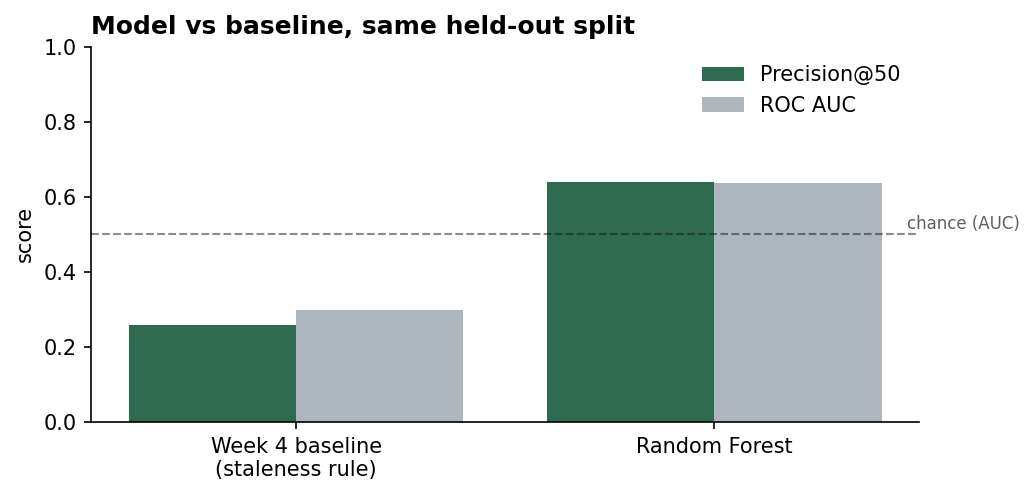

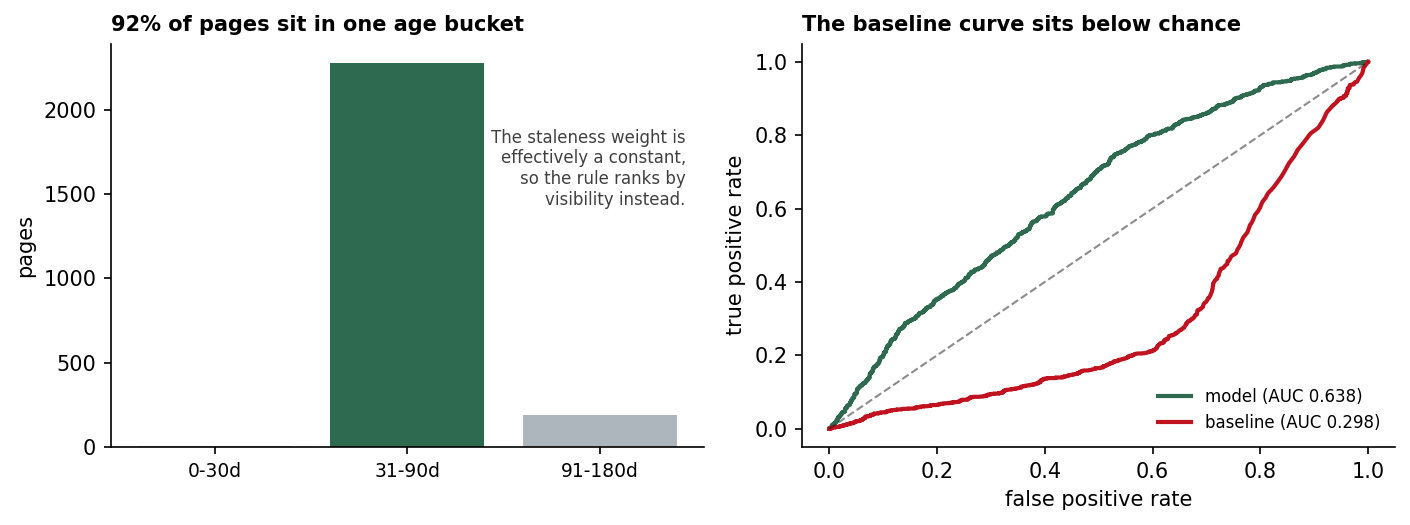

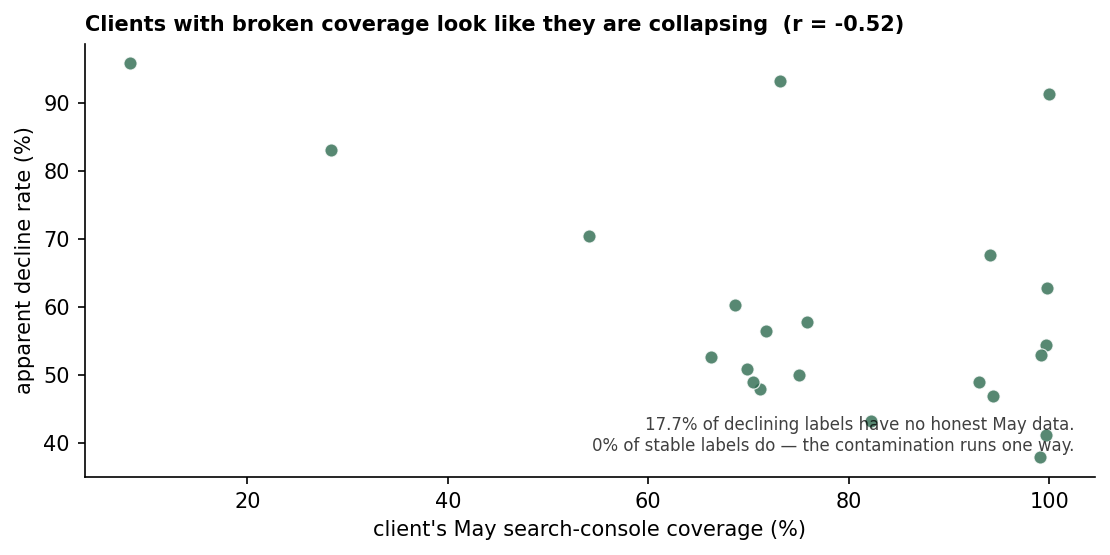

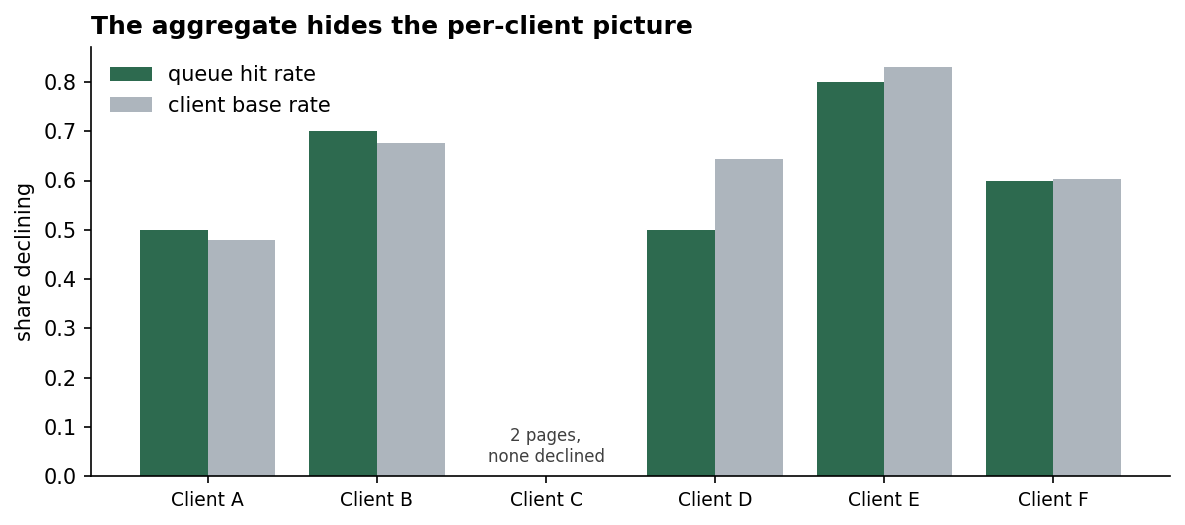

Written to work/outputs
  capstone_metrics.json  (1,021 bytes)
  capstone_queue.csv  (5,589 bytes)
  fig1_headline.png  (36,824 bytes)
  fig2_inversion.png  (89,800 bytes)
  fig3_contamination.png  (60,560 bytes)
  fig4_per_client.png  (35,421 bytes)


In [ ]:
# ============ SECTION 7 — ARTIFACTS THE PAPER EMBEDS ============
import os, json
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

OUT = "work/outputs"
os.makedirs(OUT, exist_ok=True)

client_map = {c: f"Client {chr(65+i)}" for i, c in
              enumerate(sorted(queue_df["client_hash_id"].unique()))}

plt.rcParams.update({"figure.dpi": 150, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
INK, ACC, RED, MUT = "#1a1a1a", "#2d6a4f", "#c1121f", "#adb5bd"

p50_base = p_at_k(queue_df, "baseline_score")
p50_model = p_at_k(queue_df, "risk_score")
auc_base = roc_auc_score(queue_df["is_declining_label"], queue_df["baseline_score"])
auc_model = roc_auc_score(queue_df["is_declining_label"], queue_df["risk_score"])

# ---------- FIG 1 — headline ----------
fig, ax = plt.subplots(figsize=(7, 3.4))
x = np.arange(2)
ax.bar(x - 0.2, [p50_base, p50_model], 0.4, label="Precision@50", color=ACC)
ax.bar(x + 0.2, [auc_base, auc_model], 0.4, label="ROC AUC", color=MUT)
ax.axhline(0.5, ls="--", lw=1, color=INK, alpha=.5)
ax.text(1.46, 0.515, "chance (AUC)", fontsize=8, color=INK, alpha=.7)
ax.set_xticks(x)
ax.set_xticklabels(["Week 4 baseline\n(staleness rule)", "Random Forest"])
ax.set_ylim(0, 1); ax.set_ylabel("score"); ax.legend(frameon=False)
ax.set_title("Model vs baseline, same held-out split", loc="left", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{OUT}/fig1_headline.png", bbox_inches="tight"); plt.show()

# ---------- FIG 2 — why the baseline inverted ----------
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
bd = queue_df["age_bucket"].value_counts().sort_index()
colors = [ACC if b.startswith("2)") else MUT for b in bd.index]
axes[0].bar(range(len(bd)), bd.values, color=colors)
axes[0].set_xticks(range(len(bd)))
axes[0].set_xticklabels([b.split(") ")[1] for b in bd.index], fontsize=9)
axes[0].set_ylabel("pages")
axes[0].set_title(f"{bd.max()/bd.sum():.0%} of pages sit in one age bucket",
                  loc="left", fontweight="bold", fontsize=10)
axes[0].annotate("The staleness weight is\neffectively a constant,\nso the rule ranks by\nvisibility instead.",
                 xy=(.97, .60), xycoords="axes fraction", ha="right",
                 fontsize=8, alpha=.75)

fpr_b, tpr_b, _ = roc_curve(queue_df["is_declining_label"], queue_df["baseline_score"])
fpr_m, tpr_m, _ = roc_curve(queue_df["is_declining_label"], queue_df["risk_score"])
axes[1].plot(fpr_m, tpr_m, color=ACC, lw=2, label=f"model (AUC {auc_model:.3f})")
axes[1].plot(fpr_b, tpr_b, color=RED, lw=2, label=f"baseline (AUC {auc_base:.3f})")
axes[1].plot([0, 1], [0, 1], ls="--", lw=1, color=INK, alpha=.5)
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].legend(frameon=False, fontsize=8, loc="lower right")
axes[1].set_title("The baseline curve sits below chance", loc="left",
                  fontweight="bold", fontsize=10)
plt.tight_layout(); plt.savefig(f"{OUT}/fig2_inversion.png", bbox_inches="tight"); plt.show()

# ---------- FIG 3 — the contamination ----------
bc = model_df.groupby("client_hash_id").agg(
    pages=("is_declining_label", "size"),
    dec=("is_declining_label", "mean"),
    cov=("any_may_gsc", "mean"))
bc = bc[bc["pages"] >= 30]
r = float(np.corrcoef(bc["cov"], bc["dec"])[0, 1])

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.scatter(bc["cov"] * 100, bc["dec"] * 100, s=40, color=ACC, alpha=.8,
           edgecolor="white", linewidth=.6)
ax.set_xlabel("client's May search-console coverage (%)")
ax.set_ylabel("apparent decline rate (%)")
ax.set_title(f"Clients with broken coverage look like they are collapsing  (r = {r:+.2f})",
             loc="left", fontweight="bold", fontsize=10)
ax.annotate("17.7% of declining labels have no honest May data.\n"
            "0% of stable labels do — the contamination runs one way.",
            xy=(.98, .06), xycoords="axes fraction", ha="right",
            fontsize=8, alpha=.75)
plt.tight_layout(); plt.savefig(f"{OUT}/fig3_contamination.png", bbox_inches="tight"); plt.show()

# ---------- FIG 4 — per-client reality ----------
val = queue.groupby("client_hash_id").agg(
    pages=("is_declining_label", "size"), dec=("is_declining_label", "mean"))
val["base"] = queue_df.groupby("client_hash_id")["is_declining_label"].mean()
val.index = [client_map[c] for c in val.index]

fig, ax = plt.subplots(figsize=(8, 3.6))
xx = np.arange(len(val))
ax.bar(xx - 0.2, val["dec"], 0.4, label="queue hit rate", color=ACC)
ax.bar(xx + 0.2, val["base"], 0.4, label="client base rate", color=MUT)
ax.set_xticks(xx); ax.set_xticklabels(val.index, fontsize=9)
ax.set_ylabel("share declining"); ax.legend(frameon=False, loc="upper left")
ax.set_title("The aggregate hides the per-client picture", loc="left", fontweight="bold")
for i, (_, row) in enumerate(val.iterrows()):
    if row["pages"] < 5:
        ax.annotate(f"{int(row['pages'])} pages,\nnone declined", xy=(i, 0.03),
                    ha="center", fontsize=8, alpha=.75)
plt.tight_layout(); plt.savefig(f"{OUT}/fig4_per_client.png", bbox_inches="tight"); plt.show()

# ---------- TABLES ----------
queue_export = queue[["client_hash_id", "content_hash_id", "rank_in_client", "risk_score",
                      "reason_category", "avg_position_weighted", "ctr",
                      "impressions_90d", "clicks_90d", "days_since_last_update"]].copy()
queue_export.insert(0, "client", queue_export["client_hash_id"].map(client_map))
queue_export = queue_export.drop(columns=["client_hash_id"]).sort_values(["client", "rank_in_client"])
queue_export.to_csv(f"{OUT}/capstone_queue.csv", index=False)

top50 = queue_df.nlargest(50, "risk_score")
dec50 = top50[top50["is_declining_label"] == 1]
unver = int((~dec50["any_may_gsc"]).sum())

metrics = {
    "baseline_precision_at_50": round(p50_base, 3),
    "baseline_roc_auc": round(auc_base, 3),
    "model_precision_at_50": round(p50_model, 3),
    "model_roc_auc": round(auc_model, 3),
    "test_base_rate": round(float(queue_df["is_declining_label"].mean()), 3),
    "test_rows": int(len(queue_df)),
    "test_clients": int(queue_df["client_hash_id"].nunique()),
    "largest_test_client_share": round(
        float(queue_df["client_hash_id"].value_counts().iloc[0] / len(queue_df)), 3),
    "train_rows": int(len(train_df)),
    "train_clients": int(train_df["client_hash_id"].nunique()),
    "portfolio_rows": int(len(features)),
    "labelled_rows": int(len(model_df)),
    "excluded_undefined_label": int(len(features) - len(model_df)),
    "declining_labels_missing_may_gsc": round(
        float((~model_df.loc[model_df.is_declining_label == 1, "any_may_gsc"]).mean()), 3),
    "stable_labels_missing_may_gsc": round(
        float((~model_df.loc[model_df.is_declining_label == 0, "any_may_gsc"]).mean()), 3),
    "coverage_decline_correlation": round(r, 3),
    "top50_largest_client_share": round(
        float(top50["client_hash_id"].value_counts().iloc[0] / 50), 3),
    "top50_declining": int(len(dec50)),
    "top50_declining_unverifiable": unver,
    "precision_at_50_verifiable_floor": round((len(dec50) - unver) / 50, 3),
    "queue_pages": int(len(queue)),
    "queue_hit_rate": round(float(queue["is_declining_label"].mean()), 3),
    "queue_clients_beating_base_rate": int((val["dec"] > val["base"]).sum()),
    "age_bucket_concentration": round(float(bd.max() / bd.sum()), 3),
    "feature_window": "2026-02-01 to 2026-04-30",
    "label_window": "2026-05-01 to 2026-05-31",
    "model_spec": "RandomForestClassifier(n_estimators=300, min_samples_leaf=5, "
                  "class_weight='balanced', random_state=42, n_jobs=1)",
    "sklearn_version": sklearn.__version__,
}
with open(f"{OUT}/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Written to", OUT)
for fn in sorted(os.listdir(OUT)):
    if fn.startswith(("fig", "capstone")):
        print(f"  {fn}  ({os.path.getsize(os.path.join(OUT, fn)):,} bytes)")

        ax.annotate("17.7% of declining labels have no honest May data.\n"
            "0% of stable labels do — the contamination runs one way.",
            xy=(.02, .06), xycoords="axes fraction", ha="left",
            fontsize=8, alpha=.75)

In [ ]:
from google.colab import files
import os
for f in sorted(os.listdir("work/outputs")):
    files.download(f"work/outputs/{f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
top50 = queue_df.nlargest(50, "risk_score")
dec = top50[top50["is_declining_label"] == 1]
print(f"Top 50 declining: {len(dec)}, unverifiable: {(~dec['any_may_gsc']).sum()}")
print(f"Floor: {(len(dec) - (~dec['any_may_gsc']).sum())/50:.2f}")
print(f"Queue hit rate: {queue['is_declining_label'].mean():.1%}")
print(f"Under 100 impressions: {(queue['impressions_90d'] < 100).sum()} of {len(queue)}")
print(f"No GA4: {(~queue['any_ga4_available']).sum()} of {len(queue)}")

Top 50 declining: 32, unverifiable: 14
Floor: 0.36
Queue hit rate: 59.6%
Under 100 impressions: 25 of 52
No GA4: 23 of 52


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## ML-12 — Five-minute demo outline

**0:00–0:30 · The setup**
An SEO agency has more pages than review hours. The question isn't "which pages are
declining" — it's "which twenty do I open this week." That makes it a ranking problem,
which is why everything here is measured at Precision@K rather than accuracy.

**0:30–1:30 · The baseline that pointed the wrong way**
Start with the industry heuristic: stale content decays, so rank by time since last
update. Show the ROC curve — the baseline sits *below* the diagonal at AUC 0.298. Not
weak, inverted. A team following it would have been sent to the wrong pages.
*This is the hook. Let it land before explaining it.*

**1:30–2:30 · Why it inverted**
Show the bucket chart: 92% of pages sit in one age bucket, so the staleness weight is
effectively a constant and the rule collapses into a visibility ranking. And visibility
runs the wrong way here — declining pages had *fewer* impressions and half the clicks.
Three separate observations resolving into one mechanism.

**2:30–3:30 · The label was measuring the wrong thing**
`COALESCE(may_impressions, 0)` treats a missing month as zero impressions. Zero always
clears the decline threshold, so missing data can produce a "declining" label and never
a "stable" one. 17.7% of positive labels, 0% of negatives. Show the scatter: across 22
clients, r = −0.52 between search-console coverage and apparent decline rate. Clients
whose data pipeline broke look like their content collapsed.

**3:30–4:15 · What the model is worth**
0.64 Precision@50 against a 0.26 baseline, AUC 0.638 against 0.298. Then immediately:
49 of the top 50 come from one client, 12 of 31 hits are unverifiable, and the metric
has returned five different values across five runs on a fixed seed. The direction is
solid. The magnitude isn't.

**4:15–5:00 · What I'd do next**
Fix the label, run multiple grouped folds, report per client rather than in aggregate.
Then the honest close: this ranks pages worth looking at. It doesn't predict how many
will decline, and it doesn't establish that acting on them changes anything.

**If asked one question, expect this one:** "Why didn't you just fix the label and
re-run?" Answer: because the finding is the contribution, and a corrected model is a
different piece of work reported against different numbers. It's specified and scoped
in Section 3.

## ML-12 — Social post cut

I spent eight weeks building a model to predict which web pages are about to lose
search traffic.

The most useful thing I found had nothing to do with the model.

The industry heuristic is that stale content decays — so refresh your oldest pages
first. I built that as a baseline and it scored an AUC of 0.298. Below 0.5 doesn't mean
"no signal." It means the ranking was inverted. Following it would have sent a content
team to the wrong pages.

Then it got worse. My outcome label was `COALESCE(may_impressions, 0)` — a routine SQL
idiom, correct almost everywhere. Here it meant a client whose analytics connection
lapsed got recorded as content decline. Zero always clears a decline threshold. So
missing data could produce a "declining" label and never a "stable" one.

17.7% of my positive labels. 0% of my negatives. Across 22 clients, the correlation
between search-console coverage and apparent decline rate was −0.52.

Nothing in the results table would have shown me this. The model trained fine. The
metrics looked reasonable. I only found it because I went looking.

The model ended up modestly better than the broken baseline. The audit is the part I'd
actually defend.

Built on the FlyRank ML Internship dataset — 79M rows of production search data.
Full paper and notebooks linked below.

## ML-12 — Three-sentence employer summary

I built a page-level decline-risk model on 79 million rows of production search data,
then audited it hard enough to find three reasons its headline number couldn't be
trusted as stated: a one-directional label contamination affecting 17.7% of positive
cases, an evaluation metric that returned seven different values across seven runs. on a
fixed seed, and a test set where 49 of the top 50 predictions came from a single client.
The model beat its baseline — Precision@50 of 0.64 against 0.26, AUC 0.638 against 0.298
— and I also established *why* the baseline failed, tracing an inverted ranking back to
a feature whose entire interquartile range collapsed to a single value. The work is
deployed as a public research paper with every claim bounded, every limitation
quantified, and the one known bug specified rather than quietly patched.

## Acknowledgments & data credit

Built on the **FlyRank ML Internship dataset** — a pseudonymised export of production
search performance data covering roughly 79 million daily page-level records across 37
client portfolios.

Data provided by [FlyRank](https://flyrank.ai).

All identifiers in this work are hashed. No client names, page URLs, or search query
text appear in the dataset or in this paper.